# KI und Algorithmen – Praxisnotebook

Dieses Notebook enthält:
1. Daten laden
2. Modell trainieren
3. Visualisierung und Auswertung
4. Übungen zu Hyperparametern und Feature Importances


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('Data/learning_style_classifier.csv')
X = df[['Lernzeit_h', 'Fehlzeiten', 'Hausaufgabenquote', 'Vorwissen_Test']]
y = df['Bestanden']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
rf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
print('Accuracy:', round(accuracy_score(y_test, rf.predict(X_test)), 3))


Accuracy: 0.76


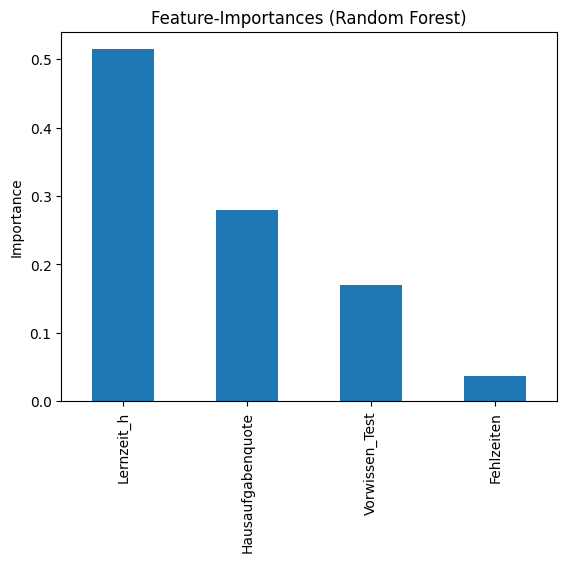

In [5]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', title='Feature-Importances (Random Forest)')
plt.ylabel('Importance')
plt.show()


## Übungen

 Testen Sie `n_estimators = 1, 20, 50, 200`, `max_depth = 5, 10, None` und `min_samples_leaf = 1, 5, 10` und dokumentieren Sie den Effekt auf Trainings- und Testgenauigkeit sowie das Overfitting-Risiko.


In [2]:
# Benötigte libraries importieren (ggf. mit `pip install ...` vorher installieren)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder



In [3]:
X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)
rng = np.random.RandomState(seed=42)
X["random_cat"] = rng.randint(3, size=X.shape[0])
X["random_num"] = rng.randn(X.shape[0])

categorical_columns = ["pclass", "sex", "embarked", "random_cat"]
numerical_columns = ["age", "sibsp", "parch", "fare", "random_num"]

X = X[categorical_columns + numerical_columns]



categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1
)
numerical_pipe = SimpleImputer(strategy="mean")

preprocessing = ColumnTransformer(
    [
        ("cat", categorical_encoder, categorical_columns),
        ("num", numerical_pipe, numerical_columns),
    ],
    verbose_feature_names_out=False,
)

rf = Pipeline(
    [
        ("preprocess", preprocessing),
        ("classifier", RandomForestClassifier(max_depth=30, n_estimators=200, min_samples_leaf=20, random_state=42)),
    ]
)
rf.fit(X_train, y_train)

# Zusammenfassende Statistiken
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
print('Trainingsgenauigkeit:', round(accuracy_score(y_train, y_train_pred), 3))
print('Testgenauigkeit:', round(accuracy_score(y_test, y_test_pred), 3))

# Konfusionsmatrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsächlich')
plt.title('Konfusionsmatrix (Random Forest)')
plt.show()

NameError: name 'X_train' is not defined